### this feeds the aal-sphere FC to vae
* code allows using all four spheres, or picking one of them

In [1]:
# Auto-Reload for Fast Iteration
%load_ext autoreload
%autoreload 2

# --- Add project root (the dir that contains 'utils/') to sys.path ---
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "utils").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT)) # insert project root at the front of the search list
print("Project root:", ROOT)  # sanity check

# Import custom functions from utils package
from utils.models import VAE, CVAE
from utils.train_utils import (
    train_vae,
    loss_function,
    get_latent_mu,
    get_latent_mu_cvae,
    compute_condition_distances
)
from utils.data_utils import (
    load_all_fc_data,
    preprocess_for_torch
)
from utils.utils_plotting import (
    plot_vae_losses,
    plot_latent_embedding_by_condition_and_subject,
    plot_subject_distance_comparison
)
from utils.bootstrap import *   # common imports, DEVICE

Project root: /Users/liuq13/project-nodeap-fmri-cvae


In [2]:
DATA_DIR = (ROOT / "data").resolve()
sub_cond_path     = DATA_DIR / "SubConds.xlsx"
base_nifti_folder = DATA_DIR / "data_FC"
condition_map = {'N': 0, 'S': 1, 'C': 2}

In [3]:
# Load and preprocess
use_roi = 0
all_corr_data, all_tms_type, all_subject_id, all_stimloc, all_session = load_all_fc_data(sub_cond_path, 
                                                               base_nifti_folder, 
                                                               mat_filename='conn_matrix_w_sphere.mat',
                                                               key_name='correlation_matrix',row_idx=use_roi)
X_tensor = preprocess_for_torch(all_corr_data)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_30/S3D2/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_44/S1D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_83/S3D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_87/D0/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_88/D0/conn_matrix_w_sphere.mat
Columns with NaN: 14 / 116
Tensor shape after preprocessing: torch.Size([331, 102])


In [4]:
# Set up model, optimizer, and device
input_dim = X_tensor.shape[1]
latent_dim = 10
NUM_EPOCH = 500
LR = 3e-4
model = VAE(input_dim=input_dim, latent_dim=latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
total_loss_hist, recon_loss_hist, kld_loss_hist = train_vae(model, dataloader, optimizer, device=DEVICE, epochs=NUM_EPOCH)


===== Epoch 1 =====


Epoch 1/500: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 292.20it/s]


Epoch 1, Loss: 107.5643, Recon: 107.1631, KL: 0.4011

===== Epoch 2 =====


Epoch 2/500: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 869.71it/s]


Epoch 2, Loss: 103.5605, Recon: 102.8975, KL: 0.6630

===== Epoch 3 =====


...

Epoch 498, Loss: 29.5759, Recon: 16.1022, KL: 13.4736

===== Epoch 499 =====


Epoch 499/500: 100%|██████████████████████████████████████████████| 11/11 [00:00<00:00, 976.39it/s]


Epoch 499, Loss: 29.0717, Recon: 15.5493, KL: 13.5224

===== Epoch 500 =====


Epoch 500/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1008.16it/s]

Epoch 500, Loss: 29.5044, Recon: 16.0406, KL: 13.4638


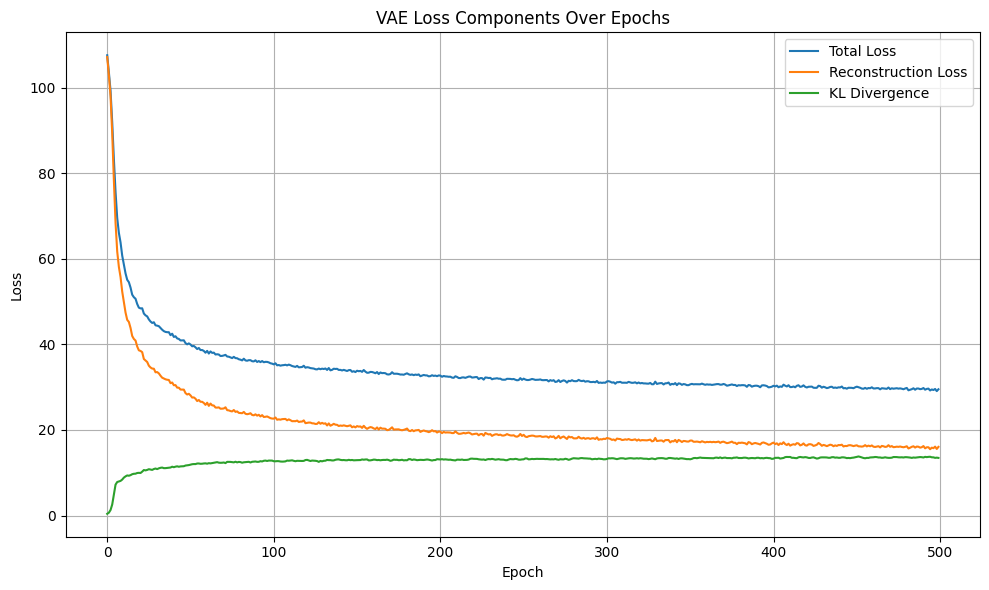

In [5]:
plot_vae_losses(total_loss_hist, recon_loss_hist, kld_loss_hist)

dim of latent mu: (331, 10)


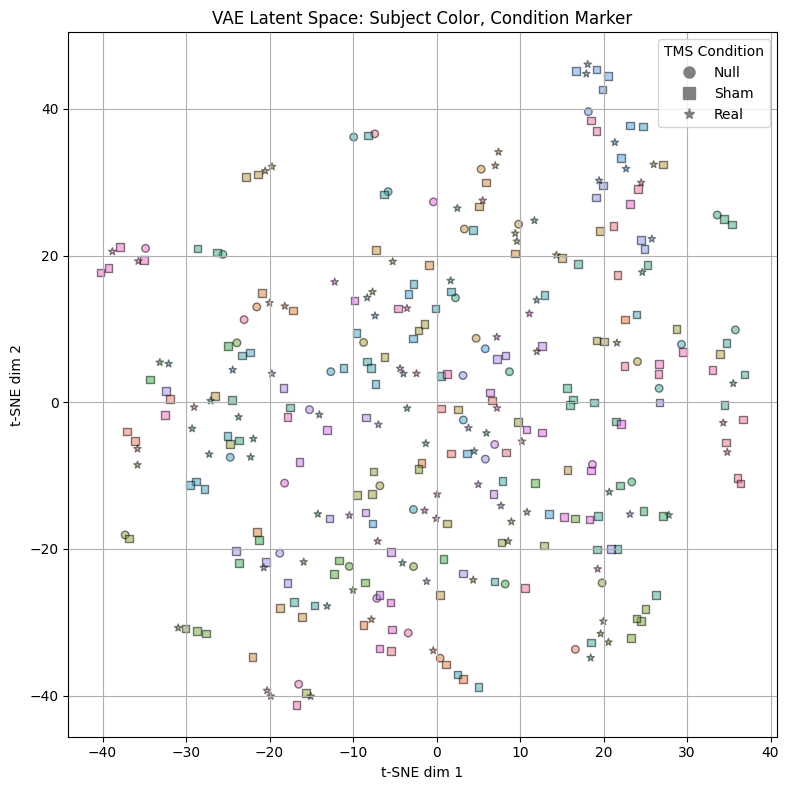

In [6]:
mu_all = get_latent_mu(model, X_tensor, device=DEVICE)
# 2d-TSNE
from sklearn.manifold import TSNE
z_2d = TSNE(n_components=2, perplexity=8).fit_transform(mu_all)
plot_latent_embedding_by_condition_and_subject(z_2d, all_tms_type, all_subject_id)

Paired t-test: t = -2.753, p = 0.0085


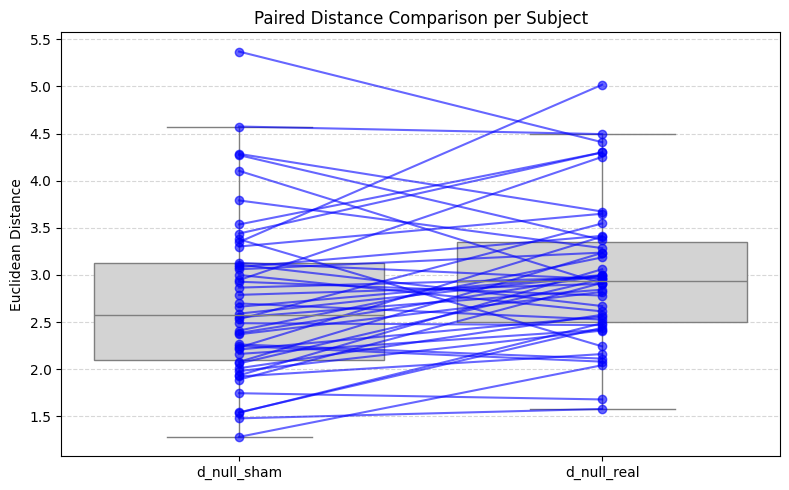

In [7]:
df = compute_condition_distances(mu_all, all_tms_type, all_subject_id, condition_map)

# Paired t-test
t_stat, p_val_t = ttest_rel(df["d_null_sham"], df["d_null_real"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.4f}")
plot_subject_distance_comparison(df)